In [1]:
# ================================
# 📦 IMPORT SECTION
# ================================
import os, sys, json, time
# Tambahkan path lokal ke modul `src/`
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
from ast import literal_eval
from typing import List, Dict, Any
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from ragas.dataset_schema import Sample, EvaluationDataset, EvaluationResult
from IPython.display import display
from tqdm import tqdm
from src.tag.src.init_llm import init_llm
from src.tag.src.text2sql_pipeline import generate_sql
from src.tag.src.query_executor import execute_text2sql_response
from src.tag.database.db_connection import connect_db
from src.tag.database.schema_loader import load_schema  
from src.tag.src.answer_generator import generate_answer
from src.tag.evaluation.eval_metrics import evaluate_end_to_end_tag


d:\code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⚠️ Intent 'date' hanya punya 1 contoh. Akan fallback ke 'general'
⚠️ Intent 'regulation' hanya punya 2 contoh. Akan fallback ke 'general'


In [5]:
load_dotenv()
conn = connect_db()
schema = load_schema(conn)

In [6]:
DATASET_PATH = os.path.join("data", "Dataset Testing Archive 2.xlsx")
df = pd.read_excel(DATASET_PATH)

dataset = []

# Filter for "is_valid" rows first, then sample
valid_df = df[df["is_valid"]]

sampled_df = valid_df.head(100)

for i, row in sampled_df.iterrows():
    dataset.append({
        "user_input": str(row["user_input"]),
        "reference_contexts": literal_eval(row["reference_contexts_2"]),
        "reference": str(row["reference"]),
        "response": str(row.get("response", ""))  # kosongkan jika belum ada
    })

print(f"Jumlah soal: {len(dataset)}")

Jumlah soal: 100


In [7]:
test_case = {
    "experiment_name": "tag_end2end_test_final",
    "shot_mode": "few-shot",
    "llm_mode": "claude",
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2"  # sesuai model RAGAS
    }

In [8]:
def retry_until_success(func, *args, max_delay=60, base_delay=5, **kwargs):
    """
    Melakukan retry berulang dengan backoff jika error Claude overload (kode 529).
    """
    delay = base_delay
    while True:
        try:
            return func(*args, **kwargs)
        except Exception as e:
            error_msg = str(e).lower()
            if "overload" in error_msg or "529" in error_msg:
                print(f"⚠️ Claude overload. Menunggu {delay} detik lalu retry...")
                time.sleep(delay)
                delay = min(delay * 2, max_delay)  # backoff maksimal 60 detik
            else:
                print(f"❌ Error bukan overload: {e}")
                raise  # error lain (misal bug prompt) tetap dilempar
            
def save_checkpoint_json(data: Any, filename: str):
    os.makedirs("samples", exist_ok=True)
    path = os.path.join("samples", filename)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False, default=str)
    print(f"✅ Saved: {filename}")

def run_end2end_combined_test_case(test_case: dict, dataset: List[Dict], resume: bool = False) -> Dict:
    """
    Gabungan evaluasi retriever + text generation dalam 1 pipeline.
    """
    print(f"\n🚀 Mulai Running End2End: {test_case['experiment_name']}")

    experiment_name = test_case["experiment_name"]
    shot_mode = test_case["shot_mode"]
    llm_mode = test_case["llm_mode"]

    autosave_path = f"samples/{experiment_name}_autosave.json"
    
    samples = []
    start_idx = 0
    
     # Cek apakah ingin resume
    if resume and os.path.exists(autosave_path):
        print(f"🔁 Resume dari autosave: {autosave_path}")
        with open(autosave_path, "r", encoding="utf-8") as f:
            samples = json.load(f)
        start_idx = len(samples)
        print(f"✅ Lanjut dari soal ke-{start_idx + 1}")
    else:
        print("🔄 Mulai dari awal.")
        

    for idx, d in enumerate(tqdm(dataset[start_idx:], desc=f"Running from {start_idx + 1}")):
        question = d["user_input"]
        reference = d["reference"]
        reference_contexts = d["reference_contexts"]

        entry = {
            "user_input": question,
            "reference_contexts": reference_contexts,
            "reference": reference
        }

        # Step 1: Generate SQL
        try:
            sql = retry_until_success(generate_sql, schema, question, top_k=100, shot_mode=shot_mode, llm_mode=llm_mode)
            entry["sql"] = sql
        except Exception as e:
            entry["error"] = f"SQL generation failed: {e}"
            samples.append(entry)
            
            continue

        # Step 2: Execute SQL
        try:
            rows, cols = execute_text2sql_response(conn, sql)
            rows = rows[:30]  # Batasi hasil maksimal 30 baris
            if not rows:
                entry["retrieved_contexts"] = ["data tidak ditemukan"]
            else:
                entry["retrieved_contexts"] = [" | ".join(map(str, row)) for row in rows]
        except Exception as e:
            print(f"[!] Error executing SQL for question: {question}")
            print(f"[!] Exception: {e}")
            try:
                conn.rollback()
                print("[ℹ️] Database rollback executed.")
            except Exception as rollback_error:
                print(f"[!] Rollback failed: {rollback_error}")
            entry["error"] = f"SQL execution failed: {e}"
            samples.append(entry)
            continue

        # Step 3: Generate Answer
        try:
            answer = retry_until_success(generate_answer, cols, rows, question, llm_mode=llm_mode)
            entry["response"] = answer
        except Exception as e:
            entry["error"] = f"Answer generation failed: {e}"
            samples.append(entry)
            continue

        samples.append(entry)

        # Autosave tiap 3 sample
        if (idx + 1) % 3 == 0:
            save_checkpoint_json(samples, f"{experiment_name}_autosave.json")
        if (idx + 1) % 3 == 0:
            print(f"Menunggu 10 detik sebelum melanjutkan...")
            time.sleep(10)

    # Final save
    save_checkpoint_json(samples, f"{experiment_name}_samples.json")
    print("✅ Evaluasi End2End selesai!")

    return {
        "experiment_name": experiment_name,
        "samples": samples
    }


In [9]:
result = run_end2end_combined_test_case(test_case, dataset)


🚀 Mulai Running End2End: tag_end2end_test_final
🔄 Mulai dari awal.


Running from 1:   2%|▏         | 2/100 [00:26<21:25, 13.12s/it]

✅ Saved: tag_end2end_test_final_autosave.json
Menunggu 10 detik sebelum melanjutkan...


Running from 1:   5%|▌         | 5/100 [01:10<21:16, 13.44s/it]

✅ Saved: tag_end2end_test_final_autosave.json
Menunggu 10 detik sebelum melanjutkan...


...

✅ Saved: tag_end2end_test_final_autosave.json
Menunggu 10 detik sebelum melanjutkan...


Running from 1:  99%|█████████▉| 99/100 [23:59<00:10, 10.96s/it]

[!] Error executing SQL for question: Pasal nomor berapa saja dalam UU Nomor 11 Tahun 2008 yang berkaitan dengan ketentuan penyebaran informasi elektronik?
[!] Exception: Error executing SQL: for SELECT DISTINCT, ORDER BY expressions must appear in select list
LINE 19:     a.article_number::integer;
             ^

[ℹ️] Database rollback executed.


Running from 1: 100%|██████████| 100/100 [24:12<00:00, 14.53s/it]

✅ Saved: tag_end2end_test_final_samples.json
✅ Evaluasi End2End selesai!


In [10]:
from langchain_huggingface import HuggingFaceEmbeddings

with open("samples/tag_end2end_test_final_samples.json", encoding="utf-8") as f:
    raw_data = json.load(f)

dataset = []
for d in raw_data:
    if "response" in d and "retrieved_contexts" in d and "reference" in d:
        dataset.append({
            "user_input": d["user_input"],
            "retrieved_contexts": d["retrieved_contexts"],
            "reference_contexts": d["reference_contexts"],
            "reference": d["reference"],
            "response": d["response"]
        })

df = pd.DataFrame(dataset)

llm_model = init_llm(mode="evaluator")
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Batasi batch size dan setup
batch_size = 7
results = []

for i in range(0, len(dataset), batch_size):
    batch = dataset[i:i + batch_size]
    batch_dataset = EvaluationDataset.from_list(batch)

    print(f"🔎 Mengevaluasi batch {i // batch_size + 1} ({len(batch)} soal)")
    result = evaluate_end_to_end_tag(
        evaluation_dataset=batch_dataset,
        llm_model=llm_model,
        embedding_model=embedding_model,
        experiment_name=f"tag_end2end_eval_batch_{i // batch_size + 1}"
    )
    results.append(result)

    # Sleep 30 detik setiap selesai batch
    if i + batch_size < len(dataset):
        print("⏳ Menunggu 30 detik sebelum lanjut ke batch berikutnya...\n")
        time.sleep(30)

print("✅ Semua batch selesai dievaluasi!")

d:\code\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


🔎 Mengevaluasi batch 1 (7 soal)


Evaluating: 100%|██████████| 42/42 [00:20<00:00,  2.03it/s]


⏳ Menunggu 30 detik sebelum lanjut ke batch berikutnya...

🔎 Mengevaluasi batch 2 (7 soal)


Evaluating: 100%|██████████| 42/42 [00:11<00:00,  3.70it/s]


...

⏳ Menunggu 30 detik sebelum lanjut ke batch berikutnya...

🔎 Mengevaluasi batch 11 (7 soal)


Evaluating:   0%|          | 0/42 [00:00<?, ?it/s]ERROR:ragas.executor:Exception raised in Job[30]: ValidationError(1 validation error for SingleTurnSample
reference
  Input should be a valid string [type=string_type, input_value=76, input_type=int]
    For further information visit https://errors.pydantic.dev/2.11/v/string_type)
ERROR:ragas.executor:Exception raised in Job[31]: ValidationError(1 validation error for SingleTurnSample
reference
  Input should be a valid string [type=string_type, input_value=76, input_type=int]
    For further information visit https://errors.pydantic.dev/2.11/v/string_type)
Evaluating: 100%|██████████| 42/42 [00:08<00:00,  5.17it/s]


⏳ Menunggu 30 detik sebelum lanjut ke batch berikutnya...

🔎 Mengevaluasi batch 12 (6 soal)


Evaluating: 100%|██████████| 36/36 [00:09<00:00,  3.63it/s]


✅ Semua batch selesai dievaluasi!


In [19]:
import pandas as pd

# Gabungkan semua batch
df_list = [result.to_pandas() for result in results]
df_all = pd.concat(df_list, ignore_index=True)

# Hitung F1 Score manual
df_all["f1_score"] = df_all.apply(
    lambda row: (2 * row["precision"] * row["recall"]) / (row["precision"] + row["recall"])
    if (row["precision"] + row["recall"]) > 0 else 0,
    axis=1
)

# Tampilkan rata-rata semua metrik
print("\n📊 RATA-RATA HASIL GABUNGAN SEMUA BATCH:")
print(df_all[[
    "precision",
    "recall",
    "f1_score",
    "rougeL_fmeasure(mode=fmeasure)",
    "answer_relevancy",
    "faithfulness",
    "nv_accuracy"
    
]].mean())


📊 RATA-RATA HASIL GABUNGAN SEMUA BATCH:
precision                         0.253564
recall                            0.312134
f1_score                          0.251592
rougeL_fmeasure(mode=fmeasure)    0.400453
answer_relevancy                  0.370230
faithfulness                      0.878735
nv_accuracy                       0.593373
dtype: float64


In [18]:
from langchain_huggingface import HuggingFaceEmbeddings

with open("samples/tag_end2end_evaluation_full.json", encoding="utf-8") as f:
    raw_data = json.load(f)

dataset = []
for d in raw_data:
    if "response" in d and "retrieved_contexts" in d and "reference" in d:
        dataset.append({
            "user_input": d["user_input"],
            "retrieved_contexts": d["retrieved_contexts"],
            "reference_contexts": d["reference_contexts"],
            "reference": d["reference"],
            "response": d["response"]
        })

df = pd.DataFrame(dataset)

llm_model = init_llm(mode="evaluator")
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Batasi batch size dan setup
batch_size = 7
results = []

for i in range(0, len(dataset), batch_size):
    batch = dataset[i:i + batch_size]
    batch_dataset = EvaluationDataset.from_list(batch)

    print(f"🔎 Mengevaluasi batch {i // batch_size + 1} ({len(batch)} soal)")
    result = evaluate_end_to_end_tag(
        evaluation_dataset=batch_dataset,
        llm_model=llm_model,
        embedding_model=embedding_model,
        experiment_name=f"tag_end2end_eval_batch_{i // batch_size + 1}"
    )
    results.append(result)

    # Sleep 30 detik setiap selesai batch
    if i + batch_size < len(dataset):
        print("⏳ Menunggu 30 detik sebelum lanjut ke batch berikutnya...\n")
        time.sleep(30)

print("✅ Semua batch selesai dievaluasi!")

d:\code\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


🔎 Mengevaluasi batch 1 (7 soal)


Evaluating: 100%|██████████| 42/42 [00:28<00:00,  1.47it/s]


⏳ Menunggu 30 detik sebelum lanjut ke batch berikutnya...

🔎 Mengevaluasi batch 2 (7 soal)


Evaluating: 100%|██████████| 42/42 [01:15<00:00,  1.80s/it]


...

⏳ Menunggu 30 detik sebelum lanjut ke batch berikutnya...

🔎 Mengevaluasi batch 11 (7 soal)


Evaluating: 100%|██████████| 42/42 [00:21<00:00,  1.93it/s]


⏳ Menunggu 30 detik sebelum lanjut ke batch berikutnya...

🔎 Mengevaluasi batch 12 (6 soal)


Evaluating: 100%|██████████| 36/36 [00:11<00:00,  3.01it/s]


✅ Semua batch selesai dievaluasi!


In [20]:
import json

# Simpan semua hasil evaluasi
eval_result = df_all.to_dict(orient="records")

with open("samples/tag_end2end_evaluation_full.json", "w", encoding="utf-8") as f:
    json.dump(eval_result, f, indent=2, ensure_ascii=False)

print("✅ Hasil evaluasi gabungan disimpan ke samples/tag_end2end_evaluation_full.json")


✅ Hasil evaluasi gabungan disimpan ke samples/tag_end2end_evaluation_full.json


In [33]:
from langchain_huggingface import HuggingFaceEmbeddings

with open("samples/end to end/claude-3-5-haiku-20241022_only.json", encoding="utf-8") as f:
    raw_data = json.load(f)

dataset = []
for d in raw_data:
    if "response" in d and "retrieved_contexts" in d and "reference" in d:
        dataset.append({
            "user_input": d["user_input"],
            # "retrieved_contexts": d["retrieved_contexts"],
            # "reference_contexts": d["reference_contexts"],
            "reference": d["reference"],
            "response": d["response"]
        })

df = pd.DataFrame(dataset)

llm_model = init_llm(mode="evaluator")
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Batasi batch size dan setup
batch_size = 7
results_llm = []

for i in range(0, len(dataset), batch_size):
    batch = dataset[i:i + batch_size]
    batch_dataset = EvaluationDataset.from_list(batch)

    print(f"🔎 Mengevaluasi batch {i // batch_size + 1} ({len(batch)} soal)")
    result = evaluate_end_to_end_tag(
        evaluation_dataset=batch_dataset,
        llm_model=llm_model,
        embedding_model=embedding_model,
        experiment_name=f"tag_end2end_eval_batch_{i // batch_size + 1}"
    )
    results_llm.append(result)

    # Sleep 30 detik setiap selesai batch
    if i + batch_size < len(dataset):
        print("⏳ Menunggu 30 detik sebelum lanjut ke batch berikutnya...\n")
        time.sleep(30)

print("✅ Semua batch selesai dievaluasi!")

d:\code\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


✅ Semua batch selesai dievaluasi!


In [31]:
import pandas as pd

# Gabungkan semua batch
df_list = [result.to_pandas() for result in results_llm]
df_all = pd.concat(df_list, ignore_index=True)

# Hitung F1 Score manual
df_all["f1_score"] = df_all.apply(
    lambda row: (2 * row["precision"] * row["recall"]) / (row["precision"] + row["recall"])
    if (row["precision"] + row["recall"]) > 0 else 0,
    axis=1
)

# Tampilkan rata-rata semua metrik
print("\n📊 RATA-RATA HASIL GABUNGAN SEMUA BATCH:")
print(df_all[[
    "precision",
    "recall",
    "f1_score",
    "rougeL_fmeasure(mode=fmeasure)",
    "answer_relevancy",
    "faithfulness",
    "nv_accuracy"
    
]].mean())

ValueError: No objects to concatenate

In [16]:
import json

# Simpan semua hasil evaluasi
eval_result_llm = df_all.to_dict(orient="records")

with open("samples/claude-3-5-haiku-20241022_only.json", "w", encoding="utf-8") as f:
    json.dump(eval_result, f, indent=2, ensure_ascii=False)

print("✅ Hasil evaluasi gabungan disimpan ke samples/.json")


✅ Hasil evaluasi gabungan disimpan ke samples/.json


In [32]:
import json
import pandas as pd

# Load the evaluation results from file
with open("samples/tag_end2end_evaluation_full.json", encoding="utf-8") as f:
    eval_result = json.load(f)

# Convert to DataFrame for easier viewing
df_result = pd.DataFrame(eval_result)

# Display the first few rows
display(df_result.head())

# Show the mean of all metric columns (exclude non-metric columns)
metric_cols = [
    "precision", "recall", "f1_score",
    "rougeL_precision(mode=precision)",
    "rougeL_recall(mode=recall)",
    "rougeL_fmeasure(mode=fmeasure)",
    "answer_relevancy", "faithfulness",
    "answer_correctness", "nv_accuracy"
]
# Only show columns that exist in df_result
metric_cols = [col for col in metric_cols if col in df_result.columns]
print("Mean of all metrics:")
print(df_result[metric_cols].mean())

,user_input,retrieved_contexts,reference_contexts,response,reference,precision,recall,rougeL_fmeasure(mode=fmeasure),answer_relevancy,faithfulness,nv_accuracy,f1_score
0,Dalam pembangunan infrastruktur telekomunikasi...,[3 | (1) Persentase TKDN untuk belanja modal (...,[(1) Persentase TKDN untuk belanja modal (cape...,Perhitungan persentase Tingkat Komponen Dalam ...,Persentase TKDN untuk belanja modal (capex) di...,1.0,0.25,0.495575,0.627684,1.000000,1.0,0.400000
1,Apakah Lembaga Penyiaran Asing boleh mendirika...,[2 | Lembaga Penyiaran Asing dilarang didirika...,[Lembaga Penyiaran Asing dilarang didirikan di...,"Tidak, Lembaga Penyiaran Asing dilarang mendir...","Tidak, Lembaga Penyiaran Asing dilarang didiri...",0.0,0.00,0.267606,0.976610,1.000000,1.0,0.000000
2,Bagaimana cara mendapatkan rekomendasi untuk m...,[52 | (1) Pelanggaran terhadap ketentuan Pasal...,[(1) Pelaksanaan Diklat REOR sebagaimana dimak...,"Berdasarkan data yang tersedia dalam dokumen, ...",Lembaga Diklat harus mengajukan permohonan kep...,0.0,0.00,0.114754,0.000000,1.000000,0.0,0.000000
3,Apa itu Jaringan Dokumentasi dan Informasi Huk...,[Jaringan Dokumentasi dan Informasi Hukum Keme...,[Dalam Peraturan Menteri ini yang dimaksud den...,JDIH Kemkominfo adalah wadah pendayagunaan ber...,JDIH Kemkominfo adalah wadah pendayagunaan ber...,0.0,0.00,0.640884,0.483137,0.363636,1.0,0.000000
4,Bagaimana proses pendaftaran Nama Domain dilak...,[21 | (1) Registrar Nama Domain Instansi sebag...,[Registri Nama Domain dan Registrar Nama Domai...,Berdasarkan Peraturan Pemerintah Nomor 71 Tahu...,Pendaftaran Nama Domain dilakukan oleh Registr...,0.2,0.50,0.234483,0.287983,1.000000,0.5,0.285714


Mean of all metrics:
precision                         0.253564
recall                            0.312134
f1_score                          0.251592
rougeL_fmeasure(mode=fmeasure)    0.400453
answer_relevancy                  0.370230
faithfulness                      0.878735
nv_accuracy                       0.593373
dtype: float64


In [21]:
import json
import pandas as pd

# Load the evaluation results from file
with open("samples/end to end/claude-3-5-haiku-20241022_only.json", encoding="utf-8") as f:
    eval_result = json.load(f)

# Convert to DataFrame for easier viewing
df_result_llm = pd.DataFrame(eval_result)

# Display the first few rows
display(df_result_llm.head())

# Show the mean of all metric columns (exclude non-metric columns)
metric_cols = [
    "precision",
    "recall",
    "f1_score",
    "rougeL_fmeasure(mode=fmeasure)",
    "answer_relevancy",
    "faithfulness",
    "nv_accuracy"
]
# Only show columns that exist in df_result
metric_cols = [col for col in metric_cols if col in df_result_llm.columns]
print("Mean of all metrics:")
print(df_result_llm[metric_cols].mean())

,user_input,response,reference,rougeL_precision(mode=precision),rougeL_recall(mode=recall),rougeL_fmeasure(mode=fmeasure),answer_relevancy,nv_accuracy
0,Dalam pembangunan infrastruktur telekomunikasi...,Dalam perhitungan persentase TKDN (Tingkat Kom...,Persentase TKDN untuk belanja modal (capex) di...,0.205128,0.285714,0.238806,0.933594,1.00
1,Apakah Lembaga Penyiaran Asing boleh mendirika...,Berdasarkan peraturan perundang-undangan di In...,"Tidak, Lembaga Penyiaran Asing dilarang didiri...",0.089286,0.263158,0.133333,0.898888,0.25
2,Bagaimana cara mendapatkan rekomendasi untuk m...,Untuk mendapatkan rekomendasi menyelenggarakan...,Lembaga Diklat harus mengajukan permohonan kep...,0.105769,0.186441,0.134969,0.955692,0.50
3,Apa itu Jaringan Dokumentasi dan Informasi Huk...,Jaringan Dokumentasi dan Informasi Hukum (JDIH...,JDIH Kemkominfo adalah wadah pendayagunaan ber...,0.233333,0.344262,0.278146,0.959575,0.50
4,Bagaimana proses pendaftaran Nama Domain dilak...,Proses pendaftaran nama domain dilakukan melal...,Pendaftaran Nama Domain dilakukan oleh Registr...,0.168142,0.441860,0.243590,0.915108,0.50


Mean of all metrics:
rougeL_fmeasure(mode=fmeasure)    0.206008
answer_relevancy                  0.706787
nv_accuracy                       0.327500
dtype: float64


,LLM + TAG,LLM Only
rougeL_fmeasure(mode=fmeasure),0.400453,0.206008
answer_relevancy,0.370230,0.706787
nv_accuracy,0.593373,0.327500


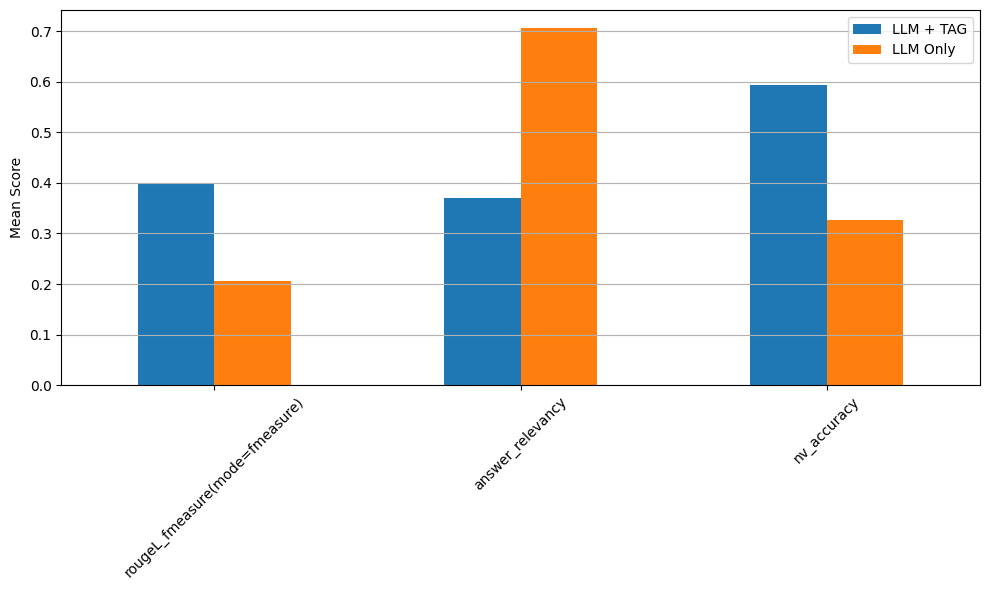

In [28]:
import matplotlib.pyplot as plt

# Metrics to compare (must exist in both DataFrames)
metrics = [
    # "rougeL_precision(mode=precision)",
    # "rougeL_recall(mode=recall)",
    "rougeL_fmeasure(mode=fmeasure)",
    "answer_relevancy",
    # "faithfullness",
    "nv_accuracy"
]

# Calculate mean for each metric
mean_df_result = df_result[metrics].mean()
mean_df_result_llm = df_result_llm[metrics].mean()

# Combine into a DataFrame for comparison
comparison_df = pd.DataFrame({
    "LLM + TAG": mean_df_result,
    "LLM Only": mean_df_result_llm
})

display(comparison_df)

# Plot comparison
comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title("")
plt.ylabel("Mean Score")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()